In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("darkgrid")
print("All libraries imported successfully!")

All libraries imported successfully!


In [11]:
# loading the CSV file into a dataframe 
df = pd.read_csv('race_data.csv')
# definng horses, cuz we gonna use this a lot
horses = ['Shadowfax', 'Iron Duke', 'Morningstar', 'Red Tide', 'Gallant Fox', 'Blue Streak', 'Copper Prince', 'Last Chance']
print("Shape of data (rows, columns):", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of data (rows, columns): (500, 10)

First 5 rows:


,race_id,Shadowfax,Iron Duke,Morningstar,Red Tide,Gallant Fox,Blue Streak,Copper Prince,Last Chance,winner
0,0,67.5041,65.6016,70.4587,73.1363,64.2286,67.2475,75.0616,75.5429,Gallant Fox
1,1,66.6415,66.0323,71.0060,72.6026,71.0442,76.8610,76.7373,72.3313,Iron Duke
2,2,67.6772,65.7881,71.0019,69.9481,70.1585,69.5850,80.5973,76.5265,Iron Duke
3,3,65.5535,67.2001,69.5425,71.2678,72.2864,73.9726,85.5591,74.9999,Shadowfax
4,4,65.3339,66.1231,69.8925,73.7591,70.4077,68.9783,70.5561,81.6178,Shadowfax


In [12]:
# --- Win Counts ---
print("How many times each horse won out of 500 races:\n")
print(df['winner'].value_counts())

print("\nAs percentages(empirical win probability):\n")
print((df['winner'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

How many times each horse won out of 500 races:

winner
Shadowfax        178
Morningstar      164
Iron Duke         74
Gallant Fox       28
Red Tide          27
Blue Streak       14
Copper Prince     10
Last Chance        5
Name: count, dtype: int64

As percentages(empirical win probability):

winner
Shadowfax        35.6%
Morningstar      32.8%
Iron Duke        14.8%
Gallant Fox       5.6%
Red Tide          5.4%
Blue Streak       2.8%
Copper Prince     2.0%
Last Chance       1.0%
Name: proportion, dtype: object


In [13]:
# --- Finishing Times Summary ---
print("Average finishing time per horse (lower = faster):\n")
print(df[horses].mean().round(2).sort_values())

print("\nStandard deviation (how consistent each horse is):\n")
print(df[horses].std().round(2).sort_values())

Average finishing time per horse (lower = faster):

Shadowfax        66.66
Morningstar      67.32
Iron Duke        68.06
Red Tide         70.15
Gallant Fox      70.88
Blue Streak      72.33
Copper Prince    74.39
Last Chance      77.59
dtype: float64

Standard deviation (how consistent each horse is):

Iron Duke        2.33
Shadowfax        2.59
Red Tide         3.17
Gallant Fox      3.50
Blue Streak      4.05
Morningstar      4.13
Copper Prince    4.84
Last Chance      6.38
dtype: float64


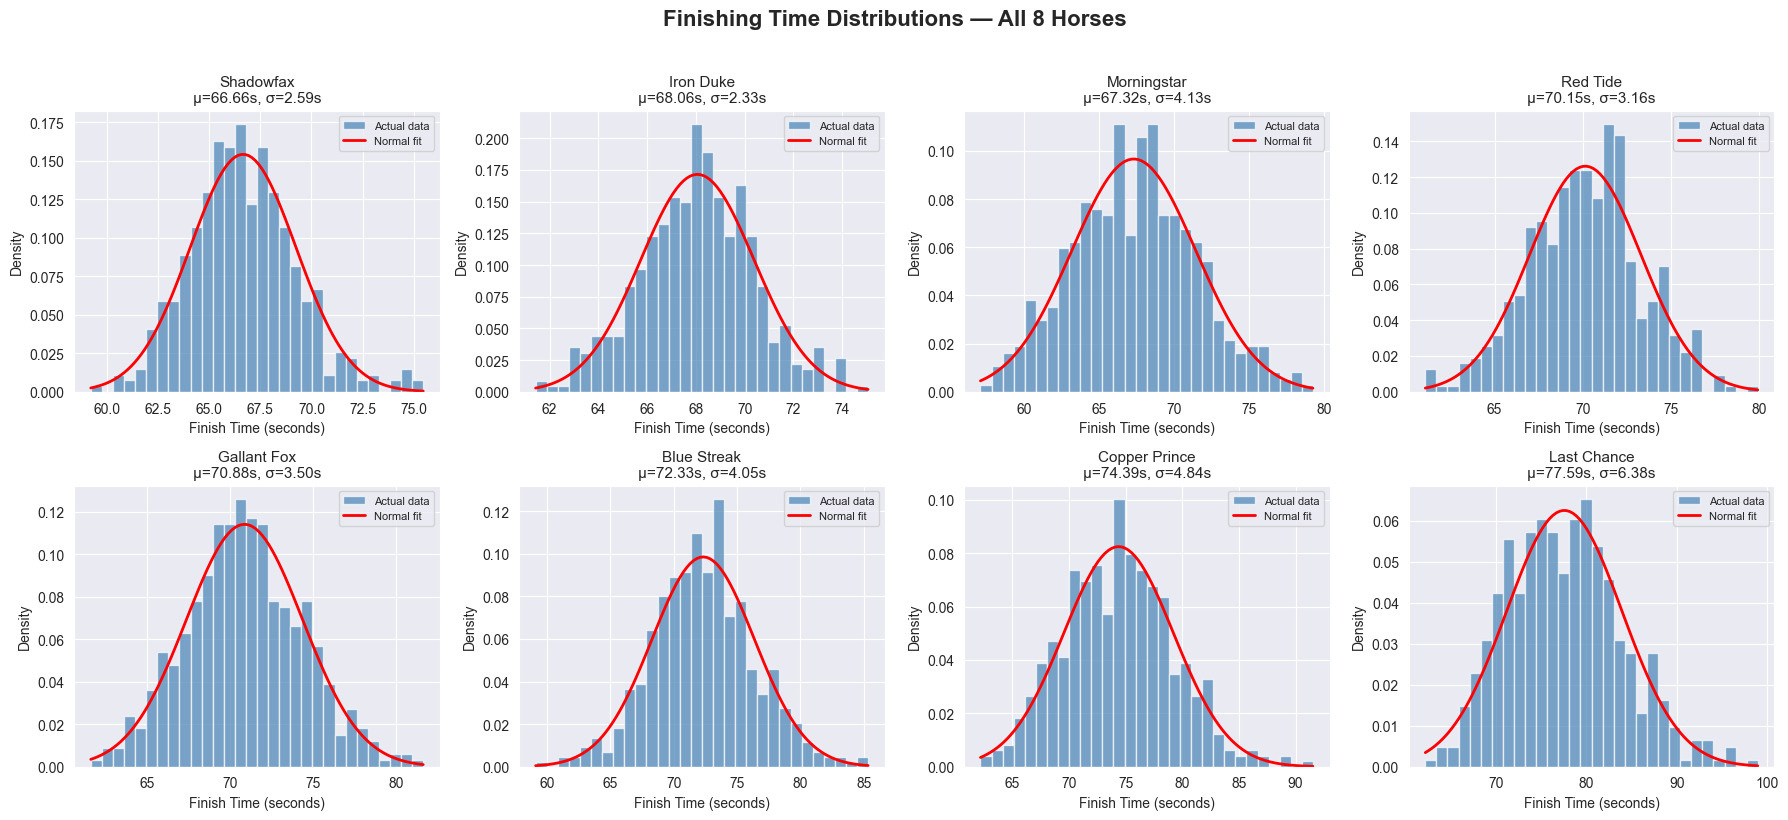

In [15]:
# Visualise the Distributions

fig, axes = plt.subplots(2, 4, figsize=(18, 8))  # 2 rows, 4 columns of charts
axes = axes.flatten()  # makes it easier to loop through

for i, horse in enumerate(horses):
    ax = axes[i]
    
    # plot a histogram of the horse's finishing times
    ax.hist(df[horse], bins=30, color='steelblue', edgecolor='white', 
            alpha=0.7, density=True, label='Actual data')
    
    # fit a normal distribution to the data
    mu, std = stats.norm.fit(df[horse])  # mu = mean, std = standard deviation
    
    # plot the fitted normal curve on top
    x = np.linspace(df[horse].min(), df[horse].max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, std), 'red', linewidth=2, label='Normal fit')
    
    # labels
    ax.set_title(f'{horse}\nμ={mu:.2f}s, σ={std:.2f}s', fontsize=11)
    ax.set_xlabel('Finish Time (seconds)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Finishing Time Distributions — All 8 Horses', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [17]:
# Monte Carlo Simulation

# first, store each horse's mean and std from the real data
means = df[horses].mean()   # average finishing time per horse
stds  = df[horses].std()    # standard deviation per horse

# number of races to simulate — more = more accurate estimates
N = 100_000

# dictionary to count how many times each horse wins
win_counts = {horse: 0 for horse in horses}

# set a random seed so results are reproducible
np.random.seed(42)

print(f"Simulating {N:,} races...")

for _ in range(N):
    # for each horse, sample a finishing time from its normal distribution
    times = {horse: np.random.normal(means[horse], stds[horse]) for horse in horses}
    
    # winner = horse with the LOWEST finishing time
    winner = min(times, key=times.get)
    
    # add 1 to that horse's win count
    win_counts[winner] += 1

# convert win counts to probabilities
true_p = {horse: win_counts[horse] / N for horse in horses}

print("Simulation complete!\n")
print("Estimated True Win Probabilities:\n")
for horse, p in sorted(true_p.items(), key=lambda x: -x[1]):
    bar = '█' * int(p * 100)
    print(f"{horse:<15} {p*100:5.1f}%  {bar}")

Simulating 100,000 races...
Simulation complete!

Estimated True Win Probabilities:

Shadowfax        32.4%  ████████████████████████████████
Morningstar      32.1%  ████████████████████████████████
Iron Duke        13.8%  █████████████
Red Tide          6.8%  ██████
Gallant Fox       5.6%  █████
Blue Streak       4.1%  ████
Copper Prince     2.8%  ██
Last Chance       2.3%  ██


In [20]:
# Expected Value Calculation

# market pool fractions (given in the problem)
pool_fractions = {
    'Shadowfax':     0.08,
    'Iron Duke':     0.09,
    'Morningstar':   0.11,
    'Red Tide':      0.13,
    'Gallant Fox':   0.14,
    'Blue Streak':   0.15,
    'Copper Prince': 0.14,
    'Last Chance':   0.16
}

print("=" * 65)
print(f"{'Horse':<15} {'True P':>8} {'Market':>8} {'EV':>8} {'Bet?':>8}")
print("=" * 65)

positive_ev_horses = []  # we'll store the good bets here

for horse in horses:
    p = true_p[horse]              # our estimated true win probability
    f = pool_fractions[horse]      # market's implied probability
    
    # EV formula from the problem
    # if EV > 0, the bet is profitable in the long run
    ev = p * (0.85 / f) - 1
    
    should_bet = "BET" if ev > 0 else "SKIP"
    
    if ev > 0:
        positive_ev_horses.append(horse)
    
    print(f"{horse:<15} {p*100:>7.1f}% {f*100:>7.1f}% {ev:>+8.4f}  {should_bet}")

print("=" * 65)
print(f"\nHorses worth betting on: {positive_ev_horses}")

Horse             True P   Market       EV     Bet?
Shadowfax          32.4%     8.0%  +2.4424  BET
Iron Duke          13.8%     9.0%  +0.3054  BET
Morningstar        32.1%    11.0%  +1.4781  BET
Red Tide            6.8%    13.0%  -0.5523  SKIP
Gallant Fox         5.6%    14.0%  -0.6592  SKIP
Blue Streak         4.1%    15.0%  -0.7682  SKIP
Copper Prince       2.8%    14.0%  -0.8276  SKIP
Last Chance         2.3%    16.0%  -0.8768  SKIP

Horses worth betting on: ['Shadowfax', 'Iron Duke', 'Morningstar']


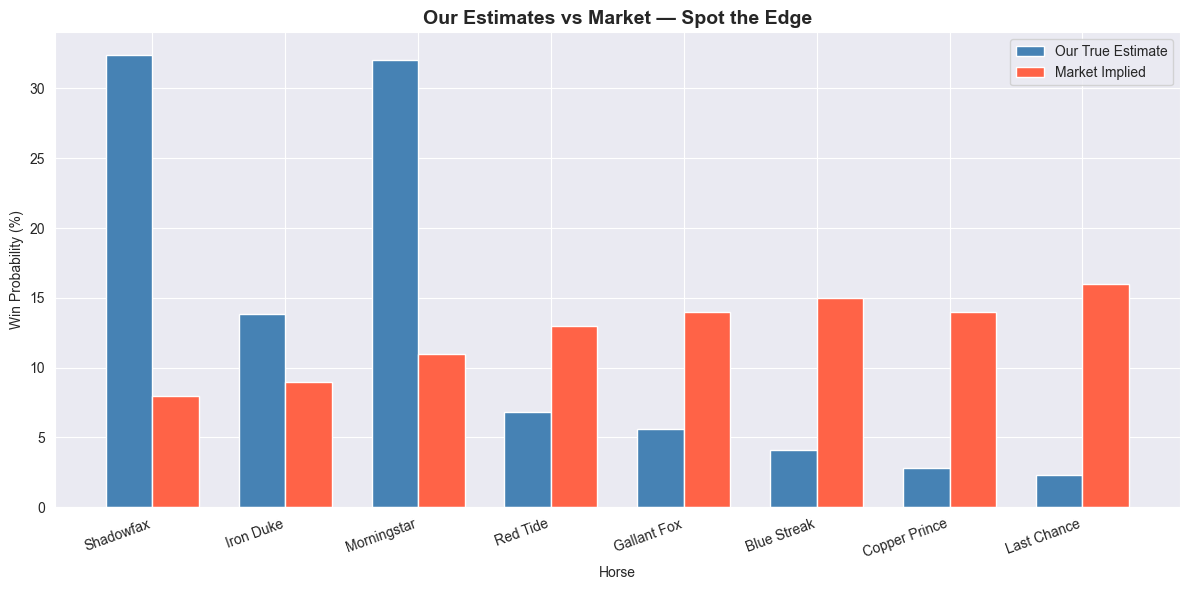

In [21]:
# --- Visualise: True P vs Market P ---

true_probs  = [true_p[h] * 100 for h in horses]
market_probs = [pool_fractions[h] * 100 for h in horses]

x = np.arange(len(horses))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, true_probs,  width, label='Our True Estimate', color='steelblue')
bars2 = ax.bar(x + width/2, market_probs, width, label='Market Implied',    color='tomato')

ax.set_xlabel('Horse')
ax.set_ylabel('Win Probability (%)')
ax.set_title('Our Estimates vs Market — Spot the Edge', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(horses, rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Kelly Criterion + Final Bet Sizes

BANKROLL = 10_000        # total money we can bet (£10,000)
KELLY_FRACTION = 0.25    # quarter-Kelly — conservative, protects against model errors

print("=" * 60)
print(f"{'Horse':<15} {'Kelly %':>8} {'Stake (£)':>10}")
print("=" * 60)

final_bets = {}
total_staked = 0

for horse in horses:
    p = true_p[horse]
    f = pool_fractions[horse]
    ev = p * (0.85 / f) - 1
    
    if ev <= 0:
        # negative EV — don't bet
        final_bets[horse] = 0.0
        print(f"{horse:<15} {'SKIP':>8} {'£0.00':>10}")
        continue
    
    # net odds: if you bet £1 and win, how much profit do you make?
    b = (0.85 / f) - 1
    
    # full kelly formula: what fraction of bankroll to bet?
    # derived from: maximise expected log(wealth)
    kelly = (p * b - (1 - p)) / b
    
    # scale down by our fraction (quarter kelly = safer)
    stake = kelly * KELLY_FRACTION * BANKROLL
    stake = round(stake, 2)
    
    final_bets[horse] = stake
    total_staked += stake
    
    print(f"{horse:<15} {kelly*100:>7.2f}% {stake:>10.2f}")

print("=" * 60)
print(f"{'TOTAL STAKED':<15} {'':>8} {total_staked:>10.2f}")
print(f"{'KEPT IN HAND':<15} {'':>8} {BANKROLL - total_staked:>10.2f}")

Horse            Kelly %  Stake (£)
Shadowfax         25.38%     634.39
Iron Duke          3.62%      90.42
Morningstar       21.97%     549.31
Red Tide            SKIP      £0.00
Gallant Fox         SKIP      £0.00
Blue Streak         SKIP      £0.00
Copper Prince       SKIP      £0.00
Last Chance         SKIP      £0.00
TOTAL STAKED                1274.12
KEPT IN HAND                8725.88



         FINAL SUBMISSION
✅ Shadowfax        £634.39
✅ Iron Duke        £90.42
✅ Morningstar      £549.31
   Red Tide         £0.00
   Gallant Fox      £0.00
   Blue Streak      £0.00
   Copper Prince    £0.00
   Last Chance      £0.00
   Total: £1274.12 / £10000.00


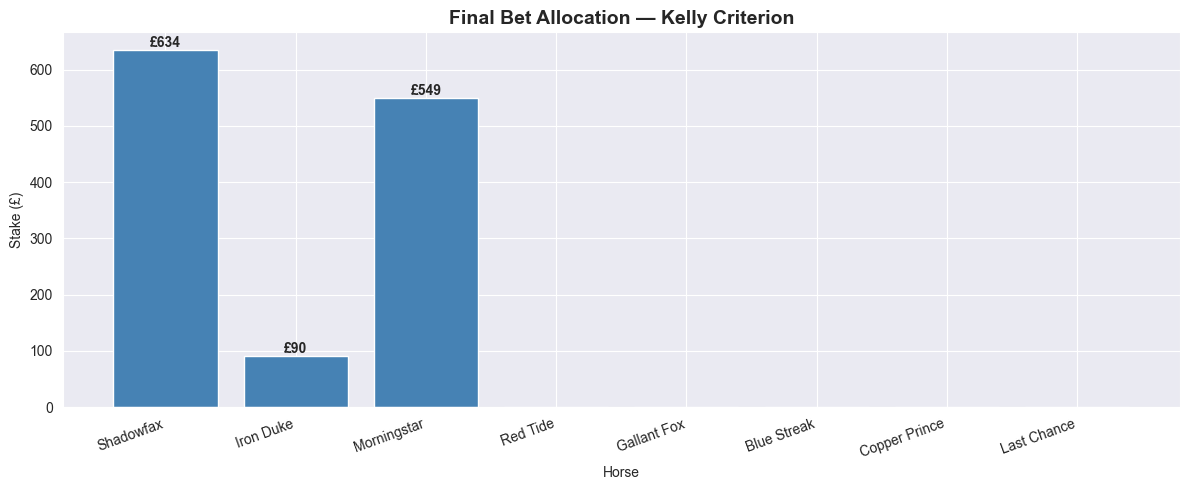

In [26]:
# --- Final Answer Summary ---

print("\n" + "=" * 40)
print("         FINAL SUBMISSION")
print("=" * 40)
for horse, stake in final_bets.items():
    status = "✅" if stake > 0 else "  "
    print(f"{status} {horse:<15}  £{stake:.2f}")
print("=" * 40)
print(f"   Total: £{total_staked:.2f} / £{BANKROLL:.2f}")
print("=" * 40)

# --- Bar chart of final bets ---
stakes = [final_bets[h] for h in horses]

plt.figure(figsize=(12, 5))
colors = ['steelblue' if s > 0 else 'lightgrey' for s in stakes]
plt.bar(horses, stakes, color=colors, edgecolor='white')
plt.title('Final Bet Allocation — Kelly Criterion', fontsize=14, fontweight='bold')
plt.xlabel('Horse')
plt.ylabel('Stake (£)')
plt.xticks(rotation=20, ha='right')

# add £ labels on top of each bar
for i, (h, s) in enumerate(zip(horses, stakes)):
    if s > 0:
        plt.text(i, s + 5, f'£{s:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()